In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_style("whitegrid")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [21]:
file_path = Path("../data/raw/CTG.xls")
raw_df = pd.read_excel(file_path, sheet_name="Data", header=None)

columns = raw_df.iloc[1].astype(str)
new_cols = []
counts = {}
for col in columns:
    if col in counts:
        counts[col] += 1
        new_cols.append(f"{col}_{counts[col]}")
    else:
        counts[col] = 0
        new_cols.append(col)

df = raw_df.iloc[2:].copy()
df.columns = new_cols

# Drop columns with 'nan' name instead of slicing to 21
df = df.loc[:, ~df.columns.str.contains('nan', na=True)]

# Convert to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop duplicates
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset Loaded Successfully")
print("Shape:", df.shape)
print("NSP in columns:", "NSP" in df.columns)

Dataset Loaded Successfully
Shape: (2119, 42)
NSP in columns: True


In [22]:
# Keep only first occurrence of each column name
df = df.loc[:, ~df.columns.duplicated()]

# Drop duplicates rows
df = df.drop_duplicates().reset_index(drop=True)

print("After removing duplicate columns:")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("NSP in columns:", "NSP" in df.columns)

After removing duplicate columns:
Shape: (2119, 42)
Columns: ['b', 'e', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'DR', 'LB', 'AC_1', 'FM_1', 'UC_1', 'DL_1', 'DS_1', 'DP_1', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance', 'Tendency', 'A', 'B', 'C', 'D', 'E', 'AD', 'DE', 'LD', 'FS', 'SUSP', 'CLASS', 'NSP']
NSP in columns: True


In [23]:
# Keep only the 21 CTG features + NSP target
ctg_features = ['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 
                'ALTV', 'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 
                'Mode', 'Mean', 'Median', 'Variance', 'Tendency', 'NSP']

df = df[ctg_features].copy()
df = df.drop_duplicates().reset_index(drop=True)

print("Final Dataset Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Missing Values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())

Final Dataset Shape: (2115, 22)
Columns: ['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance', 'Tendency', 'NSP']
Missing Values: 54
Duplicates: 0


Missing Values Per Column
LB          3
AC          3
Tendency    3
Variance    3
Median      3
Mean        3
Mode        3
Nzeros      3
Nmax        3
Max         3
Min         3
Width       3
NSP         3
MLTV        2
ALTV        2
MSTV        2
ASTV        2
UC          2
FM          2
DP          1
DS          1
DL          1
dtype: int64

Total missing: 54
% of dataset: 0.12%


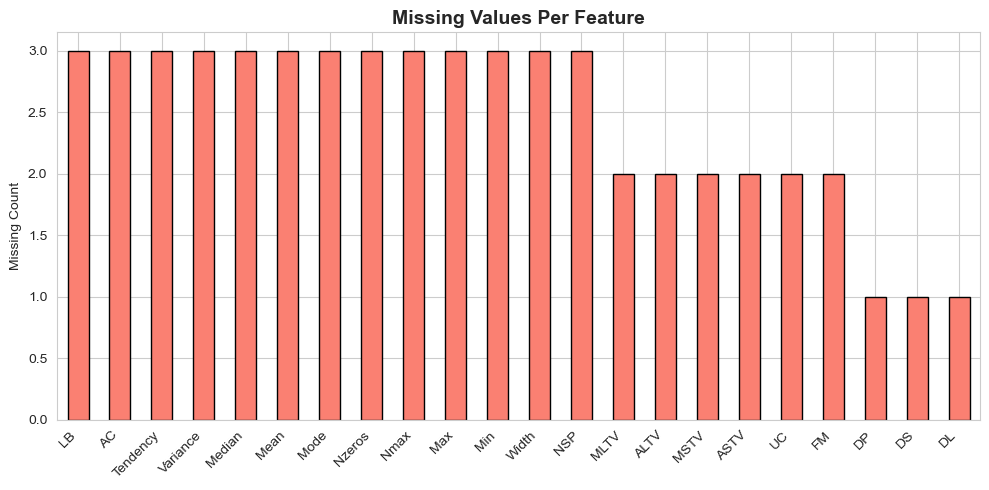

In [24]:
# Investigate missing values per column
missing_per_col = df.isnull().sum()
missing_per_col = missing_per_col[missing_per_col > 0].sort_values(ascending=False)

print("Missing Values Per Column")
print("="*50)
print(missing_per_col)
print(f"\nTotal missing: {missing_per_col.sum()}")
print(f"% of dataset: {round(missing_per_col.sum() / (df.shape[0] * df.shape[1]) * 100, 2)}%")

plt.figure(figsize=(10, 5))
missing_per_col.plot(kind="bar", color="salmon", edgecolor="black")
plt.title("Missing Values Per Feature", fontsize=14, fontweight="bold")
plt.ylabel("Missing Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../figures/missing_values.png", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
# Drop rows where NSP is missing (can't use without target label)
df = df.dropna(subset=["NSP"]).reset_index(drop=True)

print("After dropping rows with missing NSP:")
print("Shape:", df.shape)
print("Remaining missing values:", df.isnull().sum().sum())
print("\nMissing per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

After dropping rows with missing NSP:
Shape: (2112, 22)
Remaining missing values: 0

Missing per column:
Series([], dtype: int64)


Fetal Health Class Distribution
Normal (1): 1646
Suspect (2): 292
Pathological (3): 174

Class Distribution Percentages
Class 1: 77.94%
Class 2: 13.83%
Class 3: 8.24%

Imbalance Ratio (Normal:Pathological): 9.46:1
SMOTE recommended to address class imbalance


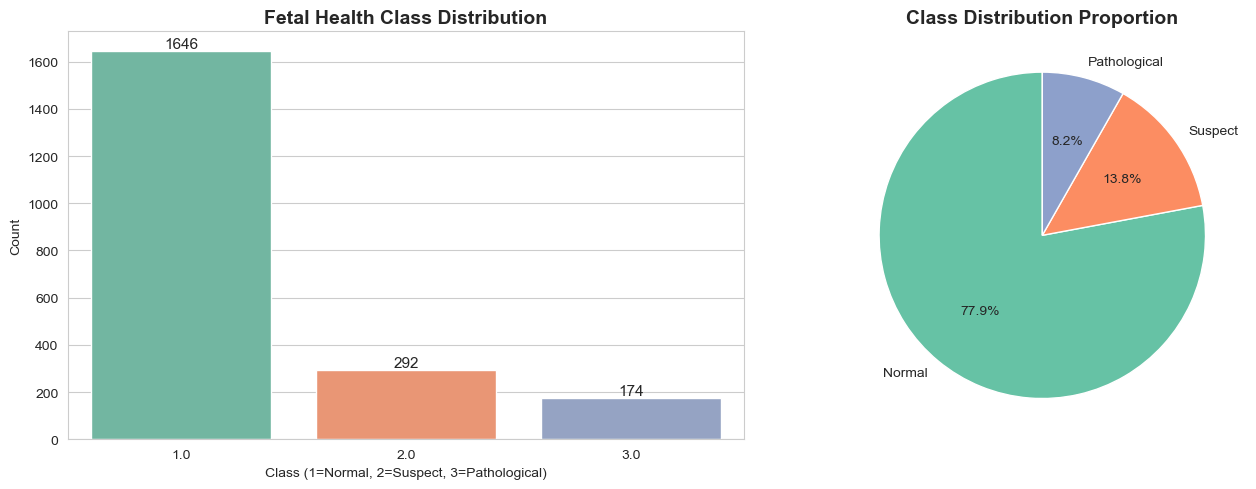

Figure saved: class_distribution.png


In [26]:
class_counts = df["NSP"].value_counts().sort_index()
total = len(df)

print("Fetal Health Class Distribution")
print("="*50)
print("Normal (1):", class_counts[1.0])
print("Suspect (2):", class_counts[2.0])
print("Pathological (3):", class_counts[3.0])

print("\nClass Distribution Percentages")
print("="*50)
for cls, count in class_counts.items():
    percentage = round((count/total)*100, 2)
    print(f"Class {int(cls)}: {percentage}%")

majority = class_counts[1.0]
minority = class_counts[3.0]
imbalance_ratio = round(majority/minority, 2)
print(f"\nImbalance Ratio (Normal:Pathological): {imbalance_ratio}:1")
print("SMOTE recommended to address class imbalance")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x=df["NSP"], palette="Set2", ax=axes[0])
axes[0].set_title("Fetal Health Class Distribution", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Class (1=Normal, 2=Suspect, 3=Pathological)")
axes[0].set_ylabel("Count")
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

axes[1].pie(class_counts.values, 
            labels=["Normal", "Suspect", "Pathological"],
            autopct="%1.1f%%", 
            colors=["#66c2a5", "#fc8d62", "#8da0cb"],
            startangle=90)
axes[1].set_title("Class Distribution Proportion", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("../figures/class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved: class_distribution.png")

In [29]:
ctg_features = ['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 
                'ALTV', 'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 
                'Mode', 'Mean', 'Median', 'Variance', 'Tendency']

summary_stats = df[ctg_features].describe().T[["mean", "std", "min", "max"]]
summary_stats = summary_stats.round(3)

print("Summary Statistics — 21 CTG Features")
print("="*50)
print(summary_stats)

summary_stats.to_csv("../data/summary_statistics.csv")
print("\nSaved to data/summary_statistics.csv")

Summary Statistics — 21 CTG Features
             mean     std    min    max
LB        133.307   9.837  106.0  160.0
AC          2.730   3.566    0.0   26.0
FM          7.528  39.120    0.0  564.0
UC          3.683   2.876    0.0   23.0
DL          1.584   2.521    0.0   16.0
DS          0.004   0.061    0.0    1.0
DP          0.128   0.473    0.0    4.0
ASTV       47.011  17.207   12.0   87.0
MSTV        1.337   0.893    0.2    7.0
ALTV        9.845  18.422    0.0   91.0
MLTV        8.190   5.705    0.0   50.7
Width      70.488  39.003    3.0  180.0
Min        93.591  29.553   50.0  159.0
Max       164.079  17.942  122.0  238.0
Nmax        4.074   2.951    0.0   18.0
Nzeros      0.325   0.707    0.0   10.0
Mode      137.452  16.396   60.0  187.0
Mean      134.601  15.605   73.0  182.0
Median    138.088  14.475   77.0  186.0
Variance   18.883  29.025    0.0  269.0
Tendency    0.319   0.611   -1.0    1.0

Saved to data/summary_statistics.csv


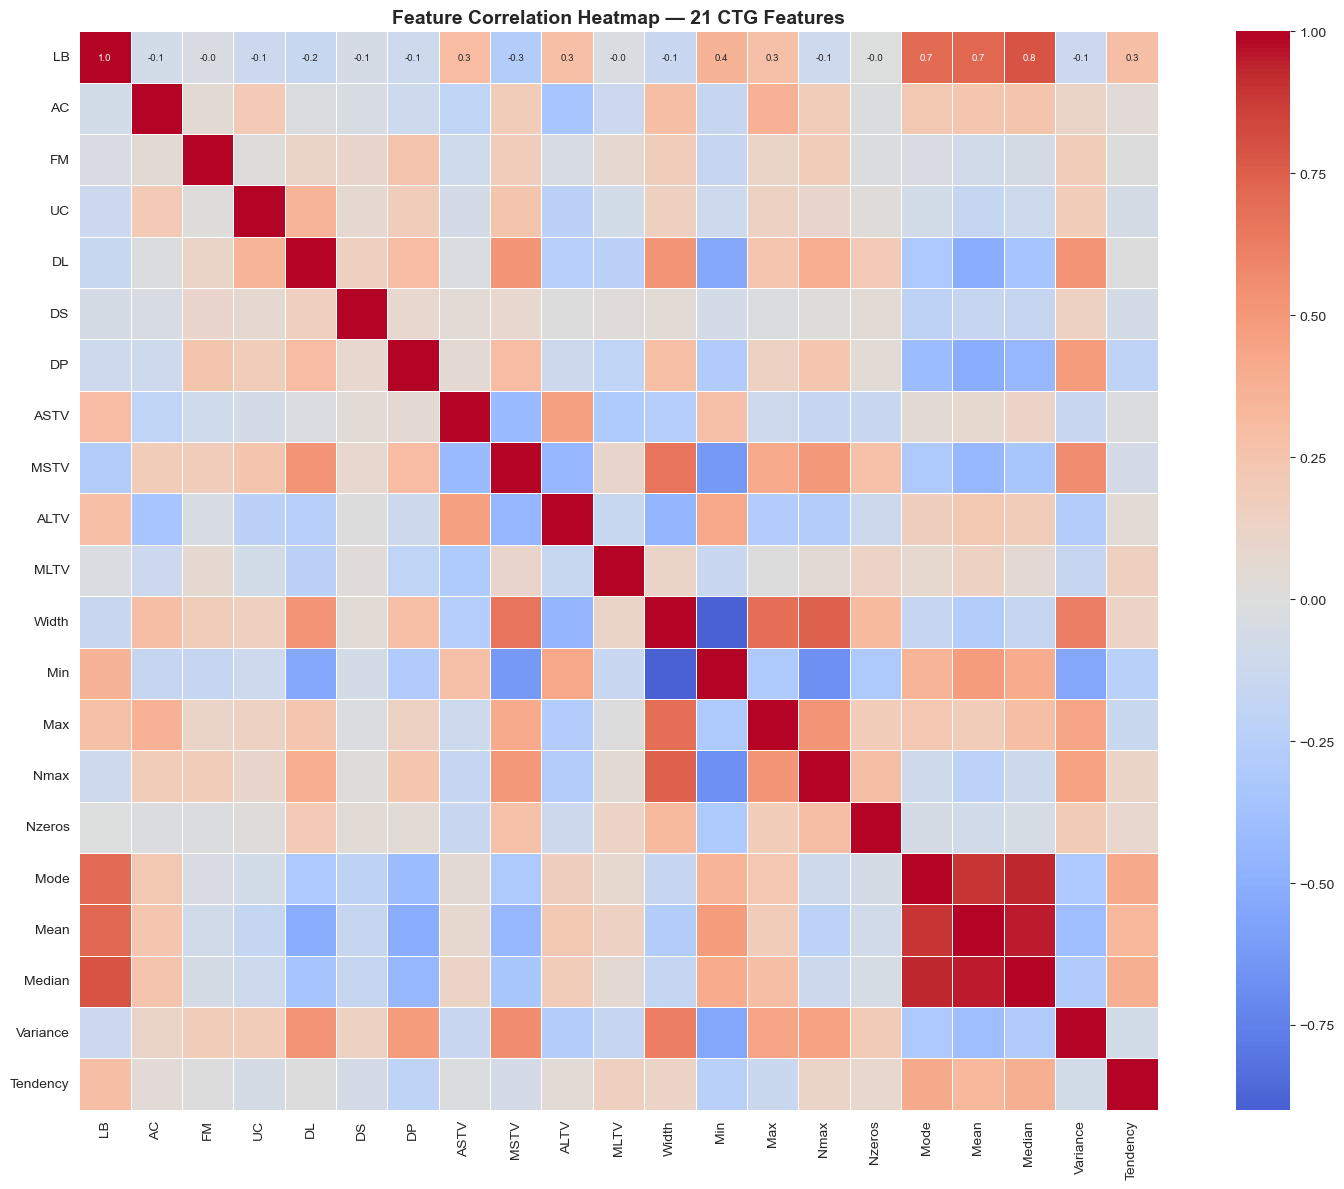

Figure saved: correlation_heatmap.png


In [30]:
corr_matrix = df[ctg_features].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    annot_kws={"size": 7}
)
plt.title("Feature Correlation Heatmap — 21 CTG Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved: correlation_heatmap.png")

Top 10 Features Correlated with Fetal Health (NSP)
DP          0.492291
ASTV        0.470225
ALTV        0.422237
AC          0.340321
Mode        0.252953
Mean        0.229598
MLTV        0.226094
Variance    0.207947
Median      0.207651
UC          0.163713
Name: NSP, dtype: float64


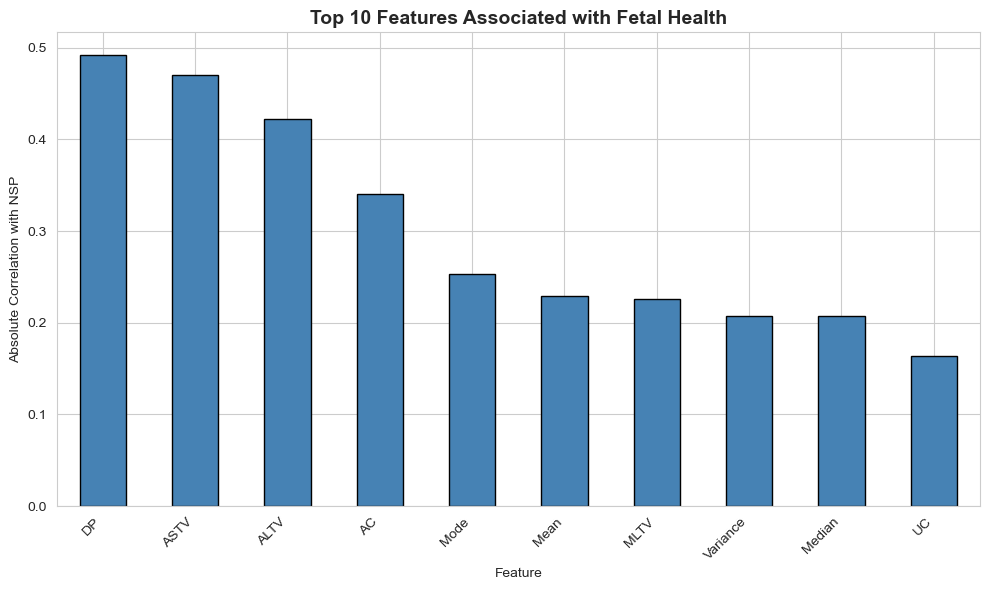

Figure saved: top_features.png


In [31]:
corr_with_nsp = df[ctg_features + ["NSP"]].corr()["NSP"].abs().sort_values(ascending=False)
top_features = corr_with_nsp[1:11]

print("Top 10 Features Correlated with Fetal Health (NSP)")
print("="*50)
print(top_features)

plt.figure(figsize=(10, 6))
top_features.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Top 10 Features Associated with Fetal Health", fontsize=14, fontweight="bold")
plt.ylabel("Absolute Correlation with NSP")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../figures/top_features.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved: top_features.png")

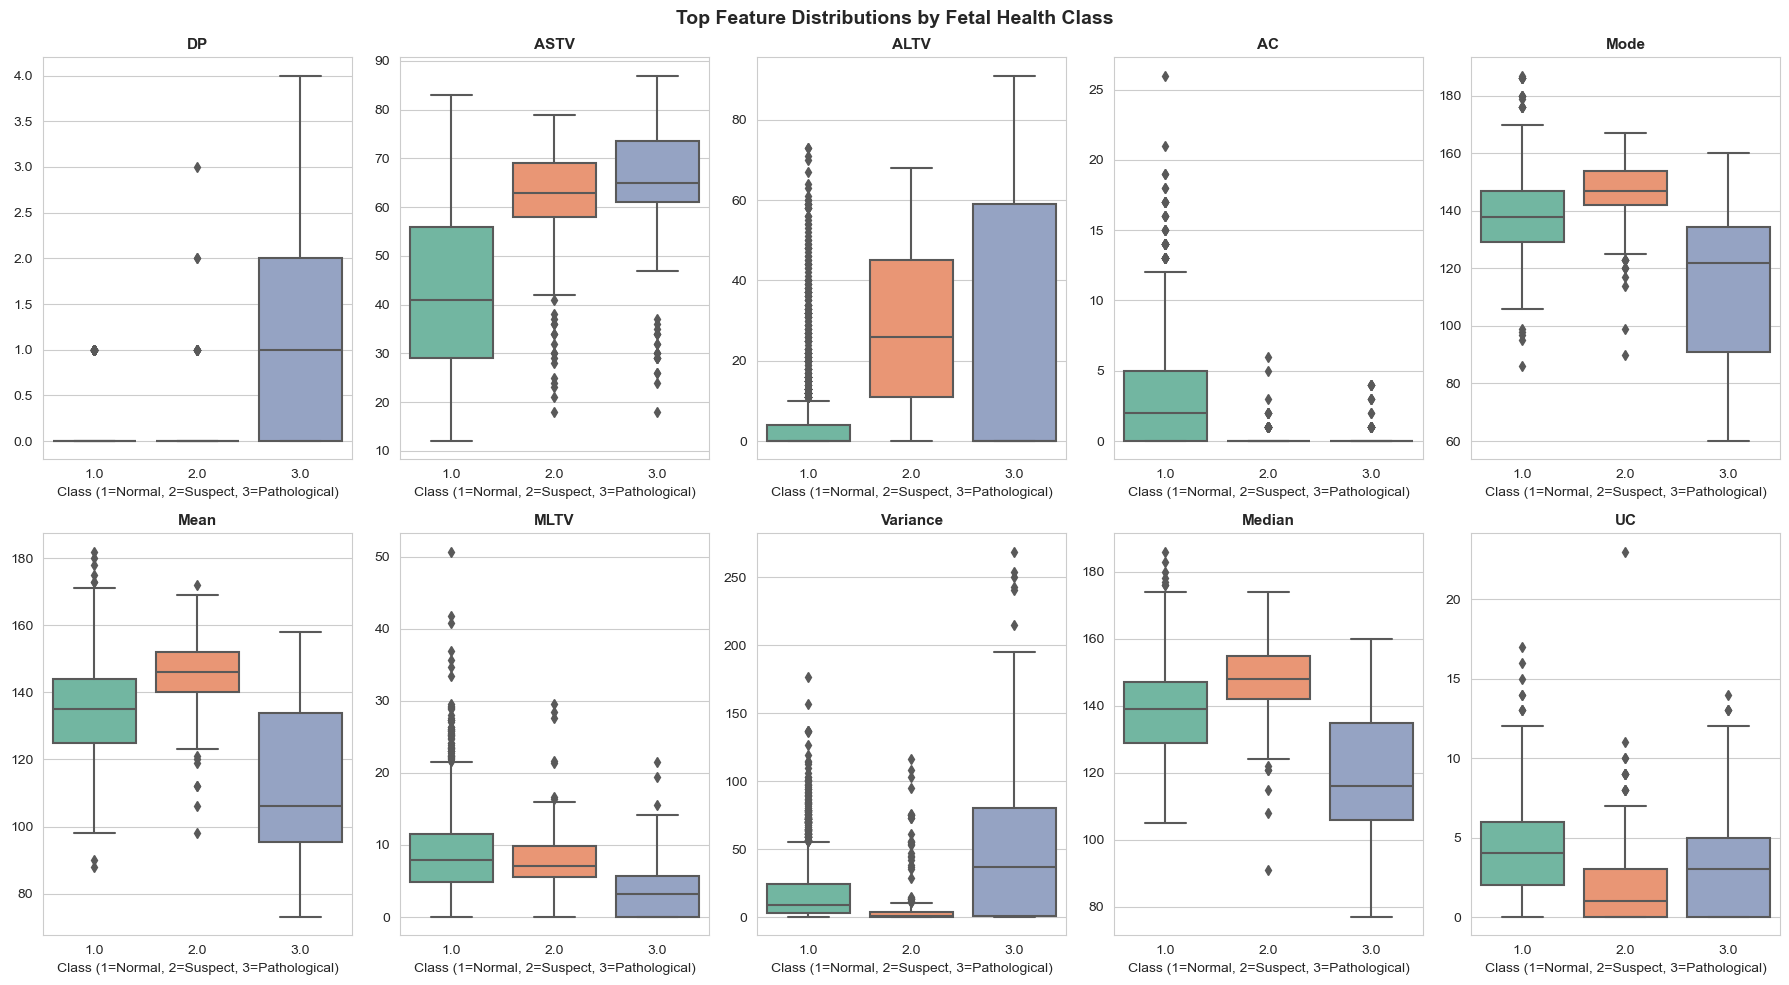

Figure saved: feature_distributions.png


In [32]:
top_feature_names = top_features.index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(top_feature_names):
    sns.boxplot(x=df["NSP"], y=df[col], palette="Set2", ax=axes[i])
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Class (1=Normal, 2=Suspect, 3=Pathological)")
    axes[i].set_ylabel("")

plt.suptitle("Top Feature Distributions by Fetal Health Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/feature_distributions.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved: feature_distributions.png")